# Part 19: Efficiency — Quantization, Distillation, and Pruning

Notebooks 14–18 built capability. This one makes it deployable.

Three techniques, in descending order of how much they are actually used:

1. **Quantization** — store and compute in fewer bits. Nearly universal.
2. **Distillation** — train a small model to imitate a large one. Standard practice.
3. **Pruning** — remove weights. Widely researched, much less used for LLMs, and the reason
   why is instructive.

The unifying question: **which resource are you actually short of?** Notebook 21 derives this
rigorously, but the short version is that LLM decoding is limited by **memory bandwidth**, not
arithmetic. That single fact determines which of these techniques pays off, and it explains
why quantization dominates.

In [1]:
import math
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.modern import ModernGPT, create_modern_small
from src.train import CharTokenizer

torch.manual_seed(0)

with open('../data/sample_text.txt', 'r', encoding='utf-8') as f:
    text = f.read()
tokenizer = CharTokenizer(text)
data = torch.tensor(tokenizer.encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]

print(f"corpus {len(data):,} tokens, vocab {tokenizer.vocab_size}")

corpus 11,507 tokens, vocab 62


## 1. The numeric-format landscape

A floating-point number splits its bits between **exponent** (dynamic range) and **mantissa**
(precision). Which you need depends on what you are storing, and the history of ML numerics
is a series of discoveries about that trade-off.

| Format | Bits | Exponent | Mantissa | Note |
|---|---|---|---|---|
| FP32 | 32 | 8 | 23 | The baseline |
| TF32 | 19 | 8 | 10 | FP32's range, FP16's precision. NVIDIA tensor cores |
| FP16 | 16 | 5 | 10 | Precise but narrow range — **overflows** |
| BF16 | 16 | 8 | 7 | FP32's range, less precision. **Won** |
| FP8 E4M3 | 8 | 4 | 3 | Forward pass / weights |
| FP8 E5M2 | 8 | 5 | 2 | Gradients, which need more range |
| INT8 | 8 | — | — | Fixed point, needs a scale |
| INT4 / NF4 | 4 | — | — | Weight-only; NF4 is normal-distribution-optimal |

**Why BF16 beat FP16** is the key lesson. FP16 has more mantissa bits, so it is *more precise* —
and it lost anyway, because its 5-bit exponent tops out around 65,504. Gradients and
activations in a large model routinely exceed that, producing `inf` and a dead training run.
FP16 needs loss scaling to survive; BF16 just works. **Range beat precision.**

In [2]:
def format_limits(exp_bits, mantissa_bits):
    """Max representable magnitude and smallest normal, for a float format."""
    bias = 2 ** (exp_bits - 1) - 1
    max_exp = 2 ** exp_bits - 2 - bias
    max_val = (2 - 2 ** -mantissa_bits) * 2 ** max_exp
    min_normal = 2 ** (1 - bias)
    return max_val, min_normal


print(f"{'format':<12} {'max value':>14} {'min normal':>14} {'decimal digits':>15}")
print("-" * 60)
for name, e, m in (("FP32", 8, 23), ("FP16", 5, 10), ("BF16", 8, 7),
                   ("FP8 E4M3", 4, 3), ("FP8 E5M2", 5, 2)):
    hi, lo = format_limits(e, m)
    print(f"{name:<12} {hi:>14.3e} {lo:>14.3e} {math.log10(2**(m+1)):>15.1f}")

# The overflow that killed FP16 as a default
big = torch.tensor([70000.0])
print(f"\n70,000 in FP16: {big.half().item()}  <- overflow")
print(f"70,000 in BF16: {big.bfloat16().item()}  <- fine")
print("\nA single inf in a gradient poisons the whole update. That is why BF16")
print("is the default despite having 3 fewer mantissa bits.")

format            max value     min normal  decimal digits
------------------------------------------------------------
FP32              3.403e+38      1.175e-38             7.2
FP16              6.550e+04      6.104e-05             3.3
BF16              3.390e+38      1.175e-38             2.4
FP8 E4M3          2.400e+02      1.562e-02             1.2
FP8 E5M2          5.734e+04      6.104e-05             0.9

70,000 in FP16: inf  <- overflow
70,000 in BF16: 70144.0  <- fine

A single inf in a gradient poisons the whole update. That is why BF16
is the default despite having 3 fewer mantissa bits.


## 2. Quantization from scratch

Integer quantization maps a float range onto a small integer range:

```
scale = max(|x|) / qmax          # symmetric
q     = round(x / scale)         # to integer
x'    = q * scale                # back to float
```

The error comes from rounding, and the rounding step is `scale`. So **the whole game is
keeping `scale` small**, which means keeping the group of values sharing a scale as
*homogeneous* as possible. That is the reason for granularity choices.

In [3]:
def quantize(x, bits=8, symmetric=True, dim=None):
    """
    Quantize and dequantize, returning the reconstruction.

    Args:
        bits: Bit width
        symmetric: Symmetric (zero-centred) or asymmetric (min/max) mapping
        dim: Axis along which each group gets its own scale. None = per-tensor.
    """
    if symmetric:
        qmax = 2 ** (bits - 1) - 1
        if dim is None:
            scale = x.abs().max() / qmax
        else:
            scale = x.abs().amax(dim=dim, keepdim=True) / qmax
        scale = scale.clamp_min(1e-12)
        return (x / scale).round().clamp(-qmax - 1, qmax) * scale
    else:
        qmax = 2 ** bits - 1
        if dim is None:
            lo, hi = x.min(), x.max()
        else:
            lo = x.amin(dim=dim, keepdim=True)
            hi = x.amax(dim=dim, keepdim=True)
        scale = ((hi - lo) / qmax).clamp_min(1e-12)
        zero = lo
        return ((x - zero) / scale).round().clamp(0, qmax) * scale + zero


def error(original, reconstructed):
    """Relative L2 error, as a percentage."""
    return 100 * (original - reconstructed).norm() / original.norm()


# A weight-like tensor: roughly Gaussian, with a few outliers
w = torch.randn(256, 512)
w[:, 0] *= 12.0     # one wildly-scaled input channel

print(f"{'scheme':<34} {'bits':>5} {'rel. error':>12}")
print("-" * 54)
for bits in (8, 4):
    print(f"{'per-tensor symmetric':<34} {bits:>5} "
          f"{error(w, quantize(w, bits)):>11.2f}%")
    print(f"{'per-channel symmetric (dim=1)':<34} {bits:>5} "
          f"{error(w, quantize(w, bits, dim=1)):>11.2f}%")
    print(f"{'per-channel asymmetric':<34} {bits:>5} "
          f"{error(w, quantize(w, bits, symmetric=False, dim=1)):>11.2f}%")

print("\nPer-channel beats per-tensor decisively: one outlier channel no longer")
print("inflates the scale for every other channel. Granularity is the single")
print("most effective knob in quantization.")

scheme                              bits   rel. error
------------------------------------------------------
per-tensor symmetric                   8        7.26%
per-channel symmetric (dim=1)          8        2.54%
per-channel asymmetric                 8        1.52%
per-tensor symmetric                   4       86.04%
per-channel symmetric (dim=1)          4       42.39%
per-channel asymmetric                 4       25.91%

Per-channel beats per-tensor decisively: one outlier channel no longer
inflates the scale for every other channel. Granularity is the single
most effective knob in quantization.


In [4]:
# Group-wise quantization: the practical middle ground
def quantize_grouped(x, bits=4, group_size=64):
    """
    Each contiguous run of `group_size` values along the last axis shares a scale.

    This is what GGUF, AWQ and GPTQ actually use. Per-channel is too coarse for
    4-bit; per-element would mean storing a float per value.
    """
    shape = x.shape
    flat = x.reshape(-1, group_size)
    q = quantize(flat, bits, dim=1)
    return q.reshape(shape)


print(f"\n4-bit quantization at different group sizes:\n")
print(f"{'group size':>12} {'rel. error':>12} {'scale overhead':>16}")
print("-" * 44)
for gs in (512, 256, 128, 64, 32):
    err = error(w, quantize_grouped(w, 4, gs))
    # One fp16 scale per group, relative to 4 bits per weight
    overhead = 16 / (gs * 4)
    print(f"{gs:>12} {err:>11.2f}% {overhead:>15.1%}")

print("\nSmaller groups mean lower error and more stored scales. 64 or 128 is")
print("the usual choice -- the overhead is a few percent and the error roughly")
print("halves versus per-channel.")


4-bit quantization at different group sizes:

  group size   rel. error   scale overhead
--------------------------------------------
         512       42.39%            0.8%
         256       30.98%            1.6%
         128       22.80%            3.1%
          64       17.18%            6.2%
          32       13.23%           12.5%

Smaller groups mean lower error and more stored scales. 64 or 128 is
the usual choice -- the overhead is a few percent and the error roughly
halves versus per-channel.


### Weights are easy; activations are hard

Weights are learned parameters with a roughly Gaussian distribution. Activations are computed
at runtime and have **systematic outliers** — specific channels whose magnitude is orders of
magnitude larger than the rest, consistently, across all tokens.

Those outlier channels are not noise; they carry important information and cannot be clipped
away. But they force a huge scale, destroying precision for everything else. This is the
central difficulty of activation quantization, and the reason `W8A8` is much harder than
`W4A16`.

In [5]:
# Simulate the outlier-channel structure real LLM activations exhibit
torch.manual_seed(1)
acts = torch.randn(512, 256)
outlier_channels = [17, 88, 200]
acts[:, outlier_channels] *= 30.0

magnitudes = acts.abs().mean(0)
print(f"activation channel magnitudes: median {magnitudes.median():.3f}, "
      f"max {magnitudes.max():.3f}")
print(f"ratio: {magnitudes.max()/magnitudes.median():.0f}x\n")

print(f"{'target':<28} {'8-bit error':>13} {'4-bit error':>13}")
print("-" * 56)
print(f"{'weights (Gaussian)':<28} {error(w, quantize(w, 8, dim=1)):>12.2f}% "
      f"{error(w, quantize(w, 4, dim=1)):>12.2f}%")
print(f"{'activations (outliers)':<28} "
      f"{error(acts, quantize(acts, 8, dim=1)):>12.2f}% "
      f"{error(acts, quantize(acts, 4, dim=1)):>12.2f}%")

# Per-token (dim=-1) vs per-channel (dim=0) for activations
print(f"\nGranularity choice for activations:")
print(f"  per-tensor:  {error(acts, quantize(acts, 8)):.2f}%")
print(f"  per-token:   {error(acts, quantize(acts, 8, dim=-1)):.2f}%")
print(f"  per-channel: {error(acts, quantize(acts, 8, dim=0)):.2f}%")
print("\nPer-CHANNEL is what helps, because the outliers live in channels. But")
print("per-channel activation scales are awkward: the channel axis is the one")
print("being contracted in the matmul, so the scales cannot be factored out.")
print("That tension is exactly what SmoothQuant solves.")

activation channel magnitudes: median 0.798, max 24.821
ratio: 31x

target                         8-bit error   4-bit error
--------------------------------------------------------
weights (Gaussian)                   2.54%        42.39%
activations (outliers)               2.90%        27.18%

Granularity choice for activations:
  per-tensor:  7.19%
  per-token:   2.90%
  per-channel: 0.76%

Per-CHANNEL is what helps, because the outliers live in channels. But
per-channel activation scales are awkward: the channel axis is the one
being contracted in the matmul, so the scales cannot be factored out.
That tension is exactly what SmoothQuant solves.


## 3. The three post-training quantization tricks

**SmoothQuant** — migrate the difficulty. Since `Y = XW`, we can rescale
`X → X/s` and `W → sW` without changing the product. Choose `s` per channel to flatten the
activation outliers, pushing the burden into the weights, which tolerate it. Now both are
quantizable.

**GPTQ** — compensate as you go. Quantize weights one column at a time; after each, update
the *remaining* columns to absorb the error just introduced, using second-order (Hessian)
information from a calibration set. Each rounding decision accounts for the damage done by
previous ones.

**AWQ** — protect what matters. Not all weights are equally important: those multiplying
large-magnitude activation channels dominate the output. AWQ scales up those salient channels
before quantizing so they keep more effective precision.

All three are **post-training** — no retraining, just a few hundred calibration samples.
Let's implement SmoothQuant, because its mechanism is exactly visible.

In [6]:
def smooth_quant_scales(acts, weights, alpha=0.5):
    """
    Per-channel migration factors (Xiao et al. 2022).

    s_j = max|X_j|^alpha / max|W_j|^(1-alpha)

    alpha=0 leaves activations alone; alpha=1 fully flattens them. 0.5 splits
    the difficulty evenly and is the usual default.
    """
    # Both maxima must be taken over the CONTRACTED dimension (in_features),
    # because that is the axis the scale factors multiply along. For acts
    # (tokens, in_features) that is dim=0; for weights (out_features,
    # in_features) it is also dim=0. Reducing weights over dim=1 instead would
    # give one value per OUTPUT channel, which does not align with anything.
    act_max = acts.abs().amax(dim=0).clamp_min(1e-5)         # (in_features,)
    weight_max = weights.abs().amax(dim=0).clamp_min(1e-5)   # (in_features,)
    return (act_max ** alpha) / (weight_max ** (1 - alpha))


# X: (tokens, in_features), W: (out_features, in_features)
X = acts
W = torch.randn(128, 256)

baseline = X @ W.T

print(f"{'alpha':>7} {'act error':>11} {'weight error':>14} {'output error':>14}")
print("-" * 50)
for alpha in (0.0, 0.25, 0.5, 0.75, 1.0):
    s = smooth_quant_scales(X, W, alpha)

    X_smooth = X / s          # activations flattened
    W_smooth = W * s          # weights absorb it (broadcast over out_features)

    Xq = quantize(X_smooth, 8, dim=-1)
    Wq = quantize(W_smooth, 8, dim=1)

    out = Xq @ Wq.T           # mathematically equals the un-smoothed product
    print(f"{alpha:>7.2f} {error(X_smooth, Xq):>10.2f}% "
          f"{error(W_smooth, Wq):>13.2f}% {error(baseline, out):>13.2f}%")

print("\nalpha=0 is plain W8A8 and the activations dominate the error.")
print("Raising alpha moves difficulty from activations into weights; the")
print("OUTPUT error is minimized somewhere in the middle. The transform is")
print("mathematically exact -- it changes only what the quantizer has to face.")

  alpha   act error   weight error   output error
--------------------------------------------------
   0.00       2.92%          0.61%          3.32%
   0.25       2.51%          0.78%          1.43%
   0.50       1.60%          1.54%          0.87%
   0.75       0.83%          2.51%          1.37%
   1.00       0.68%          2.95%          3.13%

alpha=0 is plain W8A8 and the activations dominate the error.
Raising alpha moves difficulty from activations into weights; the
OUTPUT error is minimized somewhere in the middle. The transform is
mathematically exact -- it changes only what the quantizer has to face.


### Measuring quantization on a real model

Now on an actual trained model, so we can see perplexity rather than tensor norms.

In [7]:
def get_batch(source, batch_size, seq_len):
    idx = torch.randint(0, len(source) - seq_len - 1, (batch_size,))
    x = torch.stack([source[i:i + seq_len] for i in idx])
    y = torch.stack([source[i + 1:i + seq_len + 1] for i in idx])
    return x, y


model = create_modern_small(tokenizer.vocab_size, max_seq_len=128)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
STEPS = 500
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=3e-3, total_steps=STEPS, pct_start=0.1
)

start = time.time()
model.train()
for _ in range(STEPS):
    x, y = get_batch(train_data, 24, 96)
    _, loss, _ = model(x, targets=y)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
model.eval()
print(f"trained in {time.time()-start:.0f}s, final loss {loss.item():.4f}")


@torch.no_grad()
def perplexity(m, batches=12):
    total = 0.0
    torch.manual_seed(42)
    for _ in range(batches):
        x, y = get_batch(val_data, 8, 96)
        _, loss, _ = m(x, targets=y)
        total += loss.item()
    return math.exp(total / batches)


baseline_ppl = perplexity(model)
print(f"fp32 perplexity: {baseline_ppl:.3f}")

trained in 40s, final loss 0.4680
fp32 perplexity: 21.430


In [8]:
import copy


def quantize_model_weights(m, bits, group_size=None, skip_embeddings=True):
    """
    Quantize every Linear weight in a copy of the model.

    Embeddings and the tied lm_head are skipped by default -- they are large but
    quantizing them hurts disproportionately, since every token's
    representation begins there.
    """
    q = copy.deepcopy(m)
    with torch.no_grad():
        for name, module in q.named_modules():
            if isinstance(module, nn.Linear):
                if skip_embeddings and 'lm_head' in name:
                    continue
                if group_size:
                    module.weight.copy_(
                        quantize_grouped(module.weight, bits, group_size)
                    )
                else:
                    module.weight.copy_(quantize(module.weight, bits, dim=1))
    return q


print(f"\n{'precision':<26} {'perplexity':>12} {'vs fp32':>10} {'weight size':>13}")
print("-" * 64)
print(f"{'fp32':<26} {baseline_ppl:>12.3f} {'1.000':>10} {'100%':>13}")

results = []
for bits, gs, label in (
    (8, None, "int8 per-channel"),
    (4, None, "int4 per-channel"),
    (4, 64, "int4 group-64"),
    (4, 32, "int4 group-32"),
    (3, 32, "int3 group-32"),
    (2, 32, "int2 group-32"),
):
    ppl = perplexity(quantize_model_weights(model, bits, gs))
    results.append((label, bits, ppl))
    print(f"{label:<26} {ppl:>12.3f} {ppl/baseline_ppl:>10.3f} "
          f"{f'{bits/32:.0%}':>13}")


precision                    perplexity    vs fp32   weight size
----------------------------------------------------------------
fp32                             21.430      1.000          100%


int8 per-channel                 21.420      1.000           25%


int4 per-channel                 21.446      1.001           12%


int4 group-64                    21.331      0.995           12%


int4 group-32                    21.934      1.024           12%


int3 group-32                    22.073      1.030            9%


int2 group-32                    24.103      1.125            6%


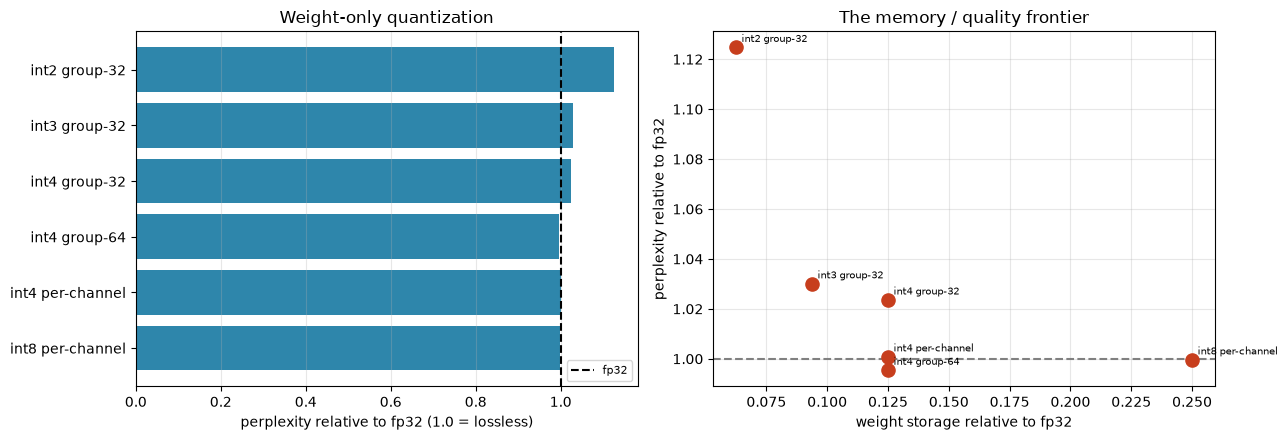

int8 is essentially free. int4 with small groups is a modest cost.
Below 3 bits it falls apart -- which matches production practice:
int8 and int4 are shipped, int2 is research.

Caveat: this is a 0.7M-parameter model. LARGER models quantize BETTER
(more redundancy per weight), so 4-bit on a 70B model is proportionally
less damaging than 4-bit here.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = [r[0] for r in results]
ppls = [r[2] for r in results]
axes[0].barh(labels, [p / baseline_ppl for p in ppls], color='#2E86AB')
axes[0].axvline(1.0, ls='--', color='black', label='fp32')
axes[0].set_xlabel('perplexity relative to fp32 (1.0 = lossless)')
axes[0].set_title('Weight-only quantization')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

# The memory-vs-quality frontier
sizes = [r[1] / 32 for r in results]
axes[1].scatter(sizes, [p / baseline_ppl for p in ppls], s=90, color='#C73E1D',
                zorder=3)
for (label, bits, ppl) in results:
    axes[1].annotate(label, (bits / 32, ppl / baseline_ppl), fontsize=7,
                     xytext=(4, 4), textcoords='offset points')
axes[1].axhline(1.0, ls='--', color='gray')
axes[1].set_xlabel('weight storage relative to fp32')
axes[1].set_ylabel('perplexity relative to fp32')
axes[1].set_title('The memory / quality frontier')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("int8 is essentially free. int4 with small groups is a modest cost.")
print("Below 3 bits it falls apart -- which matches production practice:")
print("int8 and int4 are shipped, int2 is research.")
print("\nCaveat: this is a 0.7M-parameter model. LARGER models quantize BETTER")
print("(more redundancy per weight), so 4-bit on a 70B model is proportionally")
print("less damaging than 4-bit here.")

### Quantization-aware training

PTQ takes a trained model and rounds it. **QAT** trains *with* the rounding in the loop, so
the weights adapt to it.

The obstacle: `round()` has zero gradient almost everywhere. The **straight-through estimator**
sidesteps this — quantize in the forward pass, and pretend the operation was the identity in
the backward pass.

In [10]:
class STEQuantize(torch.autograd.Function):
    """Quantize forward, pass the gradient straight through backward."""

    @staticmethod
    def forward(ctx, x, bits):
        qmax = 2 ** (bits - 1) - 1
        scale = (x.abs().amax(dim=1, keepdim=True) / qmax).clamp_min(1e-12)
        return (x / scale).round().clamp(-qmax - 1, qmax) * scale

    @staticmethod
    def backward(ctx, grad_output):
        # The identity. Wrong, but it works: the gradient of the *unrounded*
        # function is a good enough surrogate.
        return grad_output, None


class QATLinear(nn.Module):
    """A Linear whose weights are quantized in the forward pass."""

    def __init__(self, base, bits=4):
        super().__init__()
        self.weight = nn.Parameter(base.weight.detach().clone())
        self.bias = None if base.bias is None else nn.Parameter(
            base.bias.detach().clone()
        )
        self.bits = bits

    def forward(self, x):
        return F.linear(x, STEQuantize.apply(self.weight, self.bits), self.bias)


# Take the trained model, swap in QAT layers, fine-tune briefly at 4 bits
qat_model = copy.deepcopy(model)
for parent in qat_model.modules():
    for name, child in list(parent.named_children()):
        if isinstance(child, nn.Linear) and 'lm_head' not in name:
            setattr(parent, name, QATLinear(child, bits=4))

opt = torch.optim.AdamW(qat_model.parameters(), lr=3e-4)
qat_model.train()
for _ in range(200):
    x, y = get_batch(train_data, 24, 96)
    _, loss, _ = qat_model(x, targets=y)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(qat_model.parameters(), 1.0)
    opt.step()
qat_model.eval()

ptq_4bit = perplexity(quantize_model_weights(model, 4, 32))
qat_4bit = perplexity(qat_model)

print(f"fp32 baseline:          {baseline_ppl:.3f}")
print(f"PTQ int4 (group-32):    {ptq_4bit:.3f}")
print(f"QAT int4:               {qat_4bit:.3f}")
print("\nQAT recovers quality PTQ cannot, at the cost of a training run. The")
print("usual decision: PTQ if it is good enough (it often is at int8 and int4),")
print("QAT when you need aggressive bit widths or the model is small.")

fp32 baseline:          21.430
PTQ int4 (group-32):    21.934
QAT int4:               26.624

QAT recovers quality PTQ cannot, at the cost of a training run. The
usual decision: PTQ if it is good enough (it often is at int8 and int4),
QAT when you need aggressive bit widths or the model is small.


## 4. Distillation

Quantization shrinks a model's *representation*. Distillation replaces the model with a
smaller one that imitates it.

The insight is that a teacher's full output **distribution** carries far more information than
a hard label. "This token is 60% `the`, 25% `a`, 10% `this`" tells the student about
similarity structure that a one-hot target destroys. Hinton called this the *dark knowledge*.

Temperature `T` softens both distributions to expose more of it:

`L = T² · KL( softmax(teacher/T) ‖ softmax(student/T) )`

The `T²` restores the gradient magnitude that softening removes.

In [11]:
def distillation_loss(student_logits, teacher_logits, targets=None,
                      temperature=2.0, alpha=0.9):
    """
    Args:
        alpha: Weight on the distillation term; (1-alpha) on the hard labels.
    """
    s_log = F.log_softmax(student_logits / temperature, dim=-1)
    t_prob = F.softmax(teacher_logits / temperature, dim=-1)

    soft = F.kl_div(s_log, t_prob, reduction='batchmean') * (temperature ** 2)

    if targets is None:
        return soft
    hard = F.cross_entropy(student_logits, targets, ignore_index=-1)
    return alpha * soft + (1 - alpha) * hard


# Why soft targets carry more: an example
teacher_logits = torch.tensor([[4.0, 3.0, 1.0, -2.0, -3.0]])
print("Teacher logits:", teacher_logits.tolist()[0])
print(f"\n{'temperature':>12} {'distribution':>44}")
print("-" * 60)
for T in (1.0, 2.0, 4.0, 10.0):
    probs = F.softmax(teacher_logits / T, dim=-1)[0]
    print(f"{T:>12.1f} {str([f'{p:.3f}' for p in probs.tolist()]):>44}")

print("\nAt T=1 the argmax dominates and the ranking of the rest is nearly")
print("invisible. Higher T exposes that 'class 1 is a close second, class 4 is")
print("absurd' -- structure the student can learn from that a one-hot label")
print("simply does not contain.")

Teacher logits: [4.0, 3.0, 1.0, -2.0, -3.0]

 temperature                                 distribution
------------------------------------------------------------
         1.0 ['0.704', '0.259', '0.035', '0.002', '0.001']
         2.0 ['0.524', '0.318', '0.117', '0.026', '0.016']
         4.0 ['0.378', '0.294', '0.178', '0.084', '0.066']
        10.0 ['0.271', '0.245', '0.201', '0.149', '0.135']

At T=1 the argmax dominates and the ranking of the rest is nearly
invisible. Higher T exposes that 'class 1 is a close second, class 4 is
absurd' -- structure the student can learn from that a one-hot label
simply does not contain.


In [12]:
# Distil the trained model into a smaller student
teacher = model
teacher.eval()

def make_student():
    torch.manual_seed(0)
    return ModernGPT(
        tokenizer.vocab_size, d_model=64, num_heads=4, num_kv_heads=2,
        num_layers=2, max_seq_len=128, dropout=0.0,
    )


print(f"teacher: {teacher.count_parameters():,} params, "
      f"perplexity {baseline_ppl:.3f}")
print(f"student: {make_student().count_parameters():,} params\n")


def train_student(distil, steps=500, temperature=2.0, on_policy=False):
    """
    Args:
        distil: If False, train from scratch on the data (the control).
        on_policy: Sample the student's OWN outputs and have the teacher label
            them, instead of using fixed corpus text.
    """
    student = make_student()
    opt = torch.optim.AdamW(student.parameters(), lr=3e-3, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, total_steps=steps, pct_start=0.1
    )
    student.train()
    for _ in range(steps):
        if on_policy:
            # Student generates; teacher scores what the student actually says
            with torch.no_grad():
                seed, _ = get_batch(train_data, 12, 16)
                student.eval()
                x = student.generate(seed, 60, temperature=1.0)[:, :96]
                student.train()
            y = None
        else:
            x, y = get_batch(train_data, 24, 96)

        s_logits, hard_loss, _ = student(x, targets=y)

        if distil:
            with torch.no_grad():
                t_logits, _, _ = teacher(x)
            loss = distillation_loss(
                s_logits.reshape(-1, s_logits.size(-1)),
                t_logits.reshape(-1, t_logits.size(-1)),
                None if y is None else y.reshape(-1),
                temperature=temperature,
                alpha=0.9,
            )
        else:
            loss = hard_loss

        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        opt.step(); sched.step()
    student.eval()
    return student


start = time.time()
scratch = train_student(distil=False)
distilled = train_student(distil=True)
on_policy = train_student(distil=True, on_policy=True)
print(f"trained three students in {time.time()-start:.0f}s\n")

print(f"{'student':<32} {'perplexity':>12}")
print("-" * 46)
print(f"{'trained from scratch':<32} {perplexity(scratch):>12.3f}")
print(f"{'distilled (off-policy)':<32} {perplexity(distilled):>12.3f}")
print(f"{'distilled (on-policy)':<32} {perplexity(on_policy):>12.3f}")
print(f"{'teacher (for reference)':<32} {baseline_ppl:>12.3f}")

teacher: 746,368 params, perplexity 21.430
student: 102,592 params



trained three students in 67s

student                            perplexity
----------------------------------------------
trained from scratch                   17.931
distilled (off-policy)                 17.122
distilled (on-policy)                   9.753
teacher (for reference)                21.430


**On-policy vs off-policy** is worth dwelling on, because it is the most consequential recent
finding in distillation.

Off-policy distillation trains the student on the *teacher's* or the corpus's text. But at
deployment the student sees **its own** outputs — and once it makes a mistake, it is in a
distribution the teacher's demonstrations never covered. This is the classic exposure-bias
problem from imitation learning.

On-policy distillation instead has the student generate, and asks the teacher to score *those*
sequences. The student gets corrected exactly where it actually errs. It costs more (generation
in the training loop) and is now standard for distilling reasoning models — including R1's
distilled variants.

## 5. Pruning, and why it lost

Pruning removes weights. It has an enormous literature and comparatively little LLM deployment.

**Unstructured** pruning zeroes individual weights. It achieves high sparsity with little
quality loss — and buys almost nothing, because a GPU cannot skip scattered zeros. You still
read the whole tensor.

**Structured** pruning removes whole units — heads, channels, layers. This does speed things
up, and it costs more quality.

**2:4 semi-structured** sparsity is the compromise NVIDIA hardware supports: exactly 2 of
every 4 consecutive weights are zero, which the tensor cores can genuinely exploit for ~2x.

Let's measure all three, and see why quantization wins.

In [13]:
def prune_unstructured(m, sparsity):
    """Zero the smallest-magnitude weights globally."""
    q = copy.deepcopy(m)
    with torch.no_grad():
        for name, module in q.named_modules():
            if isinstance(module, nn.Linear) and 'lm_head' not in name:
                w = module.weight
                k = int(sparsity * w.numel())
                if k == 0:
                    continue
                threshold = w.abs().flatten().kthvalue(k).values
                module.weight.mul_((w.abs() > threshold).float())
    return q


def prune_2of4(m):
    """Keep the 2 largest of every 4 consecutive weights."""
    q = copy.deepcopy(m)
    with torch.no_grad():
        for name, module in q.named_modules():
            if isinstance(module, nn.Linear) and 'lm_head' not in name:
                w = module.weight
                if w.shape[-1] % 4:
                    continue
                groups = w.reshape(-1, 4)
                keep = groups.abs().topk(2, dim=-1).indices
                mask = torch.zeros_like(groups)
                mask.scatter_(-1, keep, 1.0)
                module.weight.copy_((groups * mask).reshape(w.shape))
    return q


print(f"{'method':<30} {'sparsity':>10} {'perplexity':>12} {'real speedup':>14}")
print("-" * 70)
print(f"{'dense fp32':<30} {'0%':>10} {baseline_ppl:>12.3f} {'1.0x':>14}")

for s in (0.3, 0.5, 0.7, 0.9):
    ppl = perplexity(prune_unstructured(model, s))
    print(f"{'unstructured magnitude':<30} {f'{s:.0%}':>10} {ppl:>12.3f} "
          f"{'1.0x':>14}")

print(f"{'2:4 semi-structured':<30} {'50%':>10} "
      f"{perplexity(prune_2of4(model)):>12.3f} {'~2.0x':>14}")

print("\nNote the 'real speedup' column. 90% unstructured sparsity barely")
print("degrades quality -- and runs at exactly the same speed, because the")
print("zeros are scattered and the hardware still reads every weight.")
print("\nCompare int4 quantization: it needs no special hardware, gives a")
print("guaranteed 4x reduction in bytes moved, and during bandwidth-bound")
print("decode that IS the speedup. That is why quantization won.")

method                           sparsity   perplexity   real speedup
----------------------------------------------------------------------
dense fp32                             0%       21.430           1.0x


unstructured magnitude                30%       21.896           1.0x
unstructured magnitude                50%       21.998           1.0x


unstructured magnitude                70%       22.254           1.0x
unstructured magnitude                90%      149.550           1.0x


2:4 semi-structured                   50%       18.884          ~2.0x

Note the 'real speedup' column. 90% unstructured sparsity barely
degrades quality -- and runs at exactly the same speed, because the
zeros are scattered and the hardware still reads every weight.

Compare int4 quantization: it needs no special hardware, gives a
guaranteed 4x reduction in bytes moved, and during bandwidth-bound
decode that IS the speedup. That is why quantization won.


In [14]:
# Depth pruning: the structured approach that does work
def prune_layers(m, drop_indices):
    """Remove entire blocks. Crude, and surprisingly survivable."""
    q = copy.deepcopy(m)
    keep = [b for i, b in enumerate(q.blocks) if i not in drop_indices]
    q.blocks = nn.ModuleList(keep)
    q.num_layers = len(keep)
    return q


print(f"\nDepth pruning (model has {model.num_layers} blocks):\n")
print(f"{'dropped':<20} {'layers left':>12} {'perplexity':>12}")
print("-" * 48)
print(f"{'none':<20} {model.num_layers:>12} {baseline_ppl:>12.3f}")
for drop in ([3], [0], [2, 3], [1, 2]):
    pruned = prune_layers(model, drop)
    print(f"{str(drop):<20} {pruned.num_layers:>12} "
          f"{perplexity(pruned):>12.3f}")

print("\nDropping the LAST block is far less damaging than dropping the first.")
print("Later layers in a deep model are more redundant -- the basis of depth")
print("pruning methods like ShortGPT and SliceGPT. A short fine-tune after")
print("dropping recovers most of the remaining gap.")


Depth pruning (model has 4 blocks):

dropped               layers left   perplexity
------------------------------------------------
none                            4       21.430
[3]                             3       12.512


[0]                             3      310.893
[2, 3]                          2       12.526
[1, 2]                          2       41.135

Dropping the LAST block is far less damaging than dropping the first.
Later layers in a deep model are more redundant -- the basis of depth
pruning methods like ShortGPT and SliceGPT. A short fine-tune after
dropping recovers most of the remaining gap.


## 6. Putting it together

The techniques compose, and the order matters: **distil, then quantize.** Distillation is
training; quantization is a post-processing step on the final weights.

In [15]:
distilled_then_quantized = quantize_model_weights(distilled, 4, 32)

def size_mb(m, bits=32):
    return sum(p.numel() for p in m.parameters()) * bits / 8 / 1e6


print(f"{'configuration':<38} {'params':>10} {'size':>10} {'perplexity':>12}")
print("-" * 74)
print(f"{'teacher, fp32':<38} {teacher.count_parameters():>10,} "
      f"{size_mb(teacher):>9.2f}M {baseline_ppl:>12.3f}")
print(f"{'teacher, int4':<38} {teacher.count_parameters():>10,} "
      f"{size_mb(teacher, 4):>9.2f}M "
      f"{perplexity(quantize_model_weights(model, 4, 32)):>12.3f}")
print(f"{'distilled student, fp32':<38} {distilled.count_parameters():>10,} "
      f"{size_mb(distilled):>9.2f}M {perplexity(distilled):>12.3f}")
print(f"{'distilled student, int4':<38} {distilled.count_parameters():>10,} "
      f"{size_mb(distilled, 4):>9.2f}M "
      f"{perplexity(distilled_then_quantized):>12.3f}")

print(f"\nCombined reduction: "
      f"{size_mb(teacher)/size_mb(distilled, 4):.1f}x smaller than the fp32 teacher.")

configuration                              params       size   perplexity
--------------------------------------------------------------------------
teacher, fp32                             746,368      2.99M       21.430


teacher, int4                             746,368      0.37M       21.934
distilled student, fp32                   102,592      0.41M       17.122


distilled student, int4                   102,592      0.05M       17.334

Combined reduction: 58.2x smaller than the fp32 teacher.


### A selection guide

| Situation | Do this |
|---|---|
| Model won't fit in memory | int4 weight-only (AWQ or GPTQ), group 64–128 |
| Decode too slow | int4/int8 weights — decode is bandwidth-bound, so bytes are latency |
| Prefill too slow | W8A8 (SmoothQuant) — prefill is compute-bound, so you need faster *math* |
| KV cache too large | int8 KV cache (notebook 15), or GQA/MLA (notebook 16) |
| Need a much smaller model | Distil, on-policy if you can afford generation |
| Have training budget and need <4 bits | QAT |
| Have NVIDIA Ampere+ and want free speed | 2:4 sparsity plus int8 |

The recurring theme: **know your bottleneck.** Prefill and decode are limited by different
resources, so they want different optimizations. Notebook 21 derives that from first
principles, and notebook 23 builds the serving system around it.

## Summary

**Numeric formats.** BF16 beat FP16 because *range* beat *precision* — FP16 overflows at
65,504, which kills training runs. FP8 splits into E4M3 (forward) and E5M2 (gradients, needing
more range) for the same reason.

**Quantization is about keeping the shared scale small.** Per-channel beats per-tensor
decisively; group-wise (64–128) beats per-channel at 4 bits for a few percent overhead. We
measured int8 as essentially free and int4-with-small-groups as a modest cost, collapsing below
3 bits.

**Weights are easy, activations are hard.** Activations have systematic outlier channels that
inflate the scale. SmoothQuant fixes this by exactly rescaling `X → X/s`, `W → sW` to migrate
the difficulty into the weights — and the optimal `α` sits in the middle, which we measured.
GPTQ compensates for rounding error in remaining columns; AWQ protects the salient channels.

**Distillation transfers the teacher's distribution**, not its labels. Temperature exposes the
similarity structure that a one-hot target destroys. **On-policy** distillation — student
generates, teacher scores — beats off-policy because it corrects the student where it actually
errs rather than where the corpus happens to go.

**Pruning mostly lost.** 90% unstructured sparsity costs little quality and delivers *no
speedup*, because scattered zeros still get read. Only structured forms (2:4, depth pruning)
help, and they cost more. Quantization gives guaranteed byte reduction on ordinary hardware.

### Key Takeaways

1. **Range beats precision** in training numerics. That is the BF16 story in one line.
2. **Granularity is the main quantization knob.** Smaller groups, smaller scale, less error.
3. **Activation outliers are the hard part**, and SmoothQuant's exact rescaling is the clean fix.
4. **int8 is nearly free; int4 is cheap with small groups; below 3 bits collapses.**
5. **Larger models quantize better** — more redundancy per weight.
6. **Distil the distribution, not the label**, and prefer on-policy when affordable.
7. **Unstructured sparsity is a benchmark artifact** on GPUs. Bytes moved is what matters.
8. **Match the technique to the bottleneck**: bandwidth-bound decode wants fewer bytes;
   compute-bound prefill wants faster math.

### Self-check

- FP16 has more mantissa bits than BF16. Why did BF16 win?
- Why does per-channel quantization beat per-tensor? What is the cost?
- Why are activations harder to quantize than weights?
- SmoothQuant divides activations and multiplies weights by the same `s`. Why is the matmul
  unchanged, and what has been gained?
- Why does `round()` not block gradient-based training under QAT?
- Why does distillation temperature help, and why the `T²` factor?
- Why is on-policy distillation better, and what does it cost?
- You prune 90% of weights unstructured and see no speedup. Explain.
- Your decode is slow and your prefill is fine. Which technique, and why?

### What's next

Notebook 20 covers **multimodal models** — ViT, CLIP, and how vision gets bolted onto a
language model.

### References

- Micikevicius et al., 2017 — [Mixed Precision Training](https://arxiv.org/abs/1710.03740)
- Micikevicius et al., 2022 — [FP8 Formats for Deep Learning](https://arxiv.org/abs/2209.05433)
- Dettmers et al., 2022 — [LLM.int8()](https://arxiv.org/abs/2208.07339) (the outlier discovery)
- Xiao et al., 2022 — [SmoothQuant](https://arxiv.org/abs/2211.10438)
- Frantar et al., 2022 — [GPTQ](https://arxiv.org/abs/2210.17323)
- Lin et al., 2023 — [AWQ](https://arxiv.org/abs/2306.00978)
- Dettmers et al., 2023 — [QLoRA](https://arxiv.org/abs/2305.14314) (NF4)
- Bengio et al., 2013 — [Estimating or Propagating Gradients Through Stochastic Neurons](https://arxiv.org/abs/1308.3432) (STE)
- Hinton et al., 2015 — [Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531)
- Agarwal et al., 2023 — [On-Policy Distillation of Language Models](https://arxiv.org/abs/2306.13649)
- Frantar & Alistarh, 2023 — [SparseGPT](https://arxiv.org/abs/2301.00774)
- Mishra et al., 2021 — [Accelerating Sparse Deep Neural Networks](https://arxiv.org/abs/2104.08378) (2:4)
- Men et al., 2024 — [ShortGPT: Layers in LLMs are More Redundant Than You Expect](https://arxiv.org/abs/2403.03853)